In [1]:
import os
import pandas as pd
import numpy as np
from auto_cloze import REINDEX

## Functions for compiling separate Excel sheets and calculating means/standard deviations

In [20]:
def main(L, fname, frame, metric, col):
    lists = sum([['List'+str(i)+'-1', 'List'+str(i)+'-2'] for i in range(1,int(L)+1)], [])
        
    res = []
    for i in range(int(L)):
        df = pd.DataFrame(pd.read_excel(lists[2*i]+fname+str(1)+'.xlsx', sheet_name=lists[2*i]).iloc[:,frame])
    
        j = 1
        while 1:
            try:
                df.insert(len(df.columns), col+str(j),
                          pd.read_excel(lists[2*i]+ fname+str(j)+'.xlsx', sheet_name=lists[2*i]).iloc[:,metric])
                j += 1
            except FileNotFoundError:
                print('Number of files in ', lists[2*i]+': ', j-1)
                break
                
        k = 1
        while 1:
            try:
                to_insert = pd.read_excel(lists[2*i+1]+fname+str(k)+'.xlsx', sheet_name=lists[2*i+1]).iloc[::-1]
                df.insert(len(df.columns), col+str(j+k-1), to_insert.iloc[:,metric].to_numpy())
                k += 1
            except FileNotFoundError:
                print('Number of files in ', lists[2*i+1]+': ', k-1)
                break
            
        res.append(df)
        
    new_df = res[0]
    for i in range(int(L)-1):
        new_df = pd.concat((new_df, res[i+1]), axis=0)
    
    new_df.to_excel('concatenated.xlsx', index=False)
    print('Concatenated file saved as "concatenated.xlsx" in your current working directory...')
    return new_df

In [23]:
def mean_std(file, start):
    df = pd.read_excel(file)
    
    mean, std = np.empty(len(df)), np.empty(len(df))
    for i in range(len(df)):
        ans = np.array([df.iloc[i][j] for j in range(start,len(df.columns)) if pd.isnull(df.iloc[i][j])==False])
        mean[i], std[i] = np.mean(ans), np.std(ans)
    
    df.insert(len(df.columns), 'mean', mean)
    df.insert(len(df.columns), 'std', std)
    
    df.to_excel('results.xlsx', index=False)
    print('Rating results saved as "results.xlsx" in your current working directory...')

## Reformatting all the files in one of the subfolders to make them compatable with the function `main`

In [212]:
def reformat(df):
    new_col = df.columns[0:4].to_list()*5
    df = pd.DataFrame(df.to_numpy(), columns=new_col)
    
    concat_1 = [df.iloc[0:60, 4*i:4*(i+1)] for i in range(5)]
    concat_2 = [df.iloc[61:121, 4*i:4*(i+1)] for i in range(5)]
    new_df = pd.concat([pd.concat(concat_1, axis=0), pd.concat(concat_2, axis=0)], axis=0)
    
    return new_df


def loop(L, reverse, fname, sheet_name=None):
    if reverse == 'yes': 
        lists = sum([['List'+str(i)+'-1', 'List'+str(i)+'-2'] for i in range(1,int(L)+1)], [])
    else:
        lists = ['List'+str(i) for i in range(1,int(L)+1)]
        
    res = []
    for i in range(int(L)):
        j = 1
        while 1:
            try:
                file = lists[2*i]+ fname+str(j)+'.xlsx'
                df = pd.read_excel(file, sheet_name=sheet_name)
                new_df = reformat(df)
                new_df.to_excel('<output_path>'+file, index=False)       
                j += 1
            except ValueError:
                print(file)
                j += 1
            except FileNotFoundError:
                print('Number of files in ', lists[2*i]+': ', j-1)
                break
    
        k = 1
        while 1:
            try:
                file = lists[2*i+1]+fname+str(k)+'.xlsx'
                df = pd.read_excel(file, sheet_name=sheet_name)
                new_df = reformat(df)
                new_df.to_excel('<output_path>'+file, index=False) 
                k += 1
            except ValueError:
                print(file)
                k += 1
            except FileNotFoundError:
                print('Number of files in ', lists[2*i+1]+': ', k-1)
                break

In [213]:
os.chdir('<path_to_response_sheets>')
loop(3, 'yes', '_W_fami_con_', 'Familiarity&Concreteness')

Number of files in  List1-1:  6
Number of files in  List1-2:  7
Number of files in  List2-1:  0
Number of files in  List2-2:  7
Number of files in  List3-1:  5
Number of files in  List3-2:  6


In [ ]:
os.chdir('/mnt/c/Users/jowan/Downloads/W_fami_con_reformat')
df1, df3 = pd.read_excel('List1-1_W_fami_con_1.xlsx').iloc[:,1], pd.read_excel('List3-1_W_fami_con_1.xlsx').iloc[:,1]

In [ ]:
df = pd.read_excel('List1-2_W_fami_con_1.xlsx')
index = [df1.to_list().index(x) for x in df.iloc[:,1]]
df = pd.DataFrame(df.to_numpy(), index=index, columns=df.columns)
df = df.sort_index(ascending=True)
df.iloc[::-1]

In [81]:
os.chdir('<path_to_response_sheets>')
df1 = pd.read_excel('List1-1_Best_Unexp_val_arous_1.xlsx', sheet_name='List1-1')
df2 = pd.read_excel('List2-1_Best_Unexp_val_arous_1.xlsx', sheet_name='List2-1')
df3 = pd.read_excel('List3-1_Best_Unexp_val_arous_1.xlsx', sheet_name='List3-1')
template = [df1, df2, df3]
to_sort = ['List1-2_Best_Unexp_val_arous_', 'List2-2_Best_Unexp_val_arous_', 'List3-2_Best_Unexp_val_arous_']
sheet_names = ['List1-2', 'List2-2', 'List3-2']

for i, fname in enumerate(to_sort):
    j = 1
    while 1:
        try:
            df = pd.read_excel(fname+str(j)+'.xlsx', sheet_name=sheet_names[i])
            index = [list(template[i]['詞彙']).index(x) for x in df.iloc[:,0]]
            df = pd.DataFrame(df.to_numpy(), index=index, columns=df.columns)
            df = df.sort_index(ascending=True)
            df.iloc[::-1].to_excel('<output_path>'+fname+str(j)+'.xlsx',
                                   sheet_name=sheet_names[i], index=False)
            j += 1
        except FileNotFoundError:
            break 

In [ ]:
df = pd.read_excel('results_S_plaus_exp.xlsx', sheet_name='S_exp')
df = df2.reindex(REINDEX(df['mean'])).iloc[::-1]
df.to_excel('res_S_plaus.xlsx')

## Adding back the sentence indices (condition identifiers) and their best/unexpected completion

In [ ]:
os.chdir('<path_to_pwd>')
sent_info = pd.read_excel('sentence_info.xlsx', sheet_name='All_Sentences')
sent_info

In [50]:
os.chdir('<path_to_response_sheets>')
S_arous = pd.read_excel('resultsIDX_S_val_arous.xlsx', sheet_name='S_arous')

all_sframes = list(sent_info['Sframes'])
idx = [sent_info['Index'][all_sframes.index(i[0:-3])] for i in S_arous['Sframes']]

S_arous.insert(0, 'Index', idx)
S_arous.to_excel('test.xlsx')

In [18]:
os.chdir('C:\\Users\\amand\\ratings_scripts\\S_plaus_exp')
df = pd.read_excel('resultsIDX_S_plaus_exp.xlsx', sheet_name='S_plaus')

df_styled = df.style.apply(lambda col: ['color: orange' if df['mean'][i] < 4.5 else None for i in range(len(col))],
                           subset=['Sframes','mean'])

df_styled.to_excel('plaus_test.xlsx')

## Expectancy & Cloze scatter plot; expectancy & plausibility correlation

In [ ]:
os.chdir('<path_to_results_sheet>')
exp = pd.read_excel('resultsIDX_S_plaus_exp.xlsx', sheet_name='S_exp')

os.chdir('<path_to_pwd>')
sent_info = pd.read_excel('sentence_info.xlsx', sheet_name='All_Sentences')

best_cloze = [sent_info['Constraint'][list(sent_info['Sframes']).index(y)] if y in list(sent_info['Sframes']) 
              and x[0:-1] == list(sent_info['Optimal'])[list(sent_info['Sframes']).index(y)]
              else 0
              for (i,x), (j,y) in zip(enumerate(list(exp['Completion'])), enumerate(list(exp['Sframes'])))]

In [131]:
exp.insert(len(exp.columns), 'cloze', best_cloze)
exp.to_excel('exp_cloze.xlsx')

exp_cloze = pd.read_excel('exp_cloze.xlsx')
X = np.array(exp_cloze['cloze'])
Y = np.array(exp_cloze['mean'])

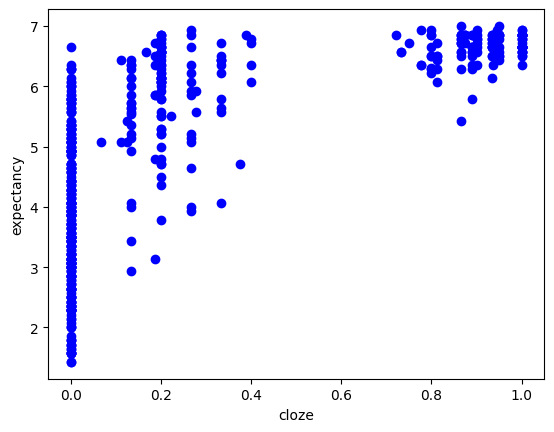

In [133]:
import matplotlib.pyplot as plt
plt.scatter(X, Y, c ="blue")
plt.xlabel('cloze')
plt.ylabel('expectancy')
plt.show()

In [136]:
x = pd.read_excel('resultsIDX_S_plaus_exp.xlsx', sheet_name='S_plaus')['mean']
y = pd.read_excel('resultsIDX_S_plaus_exp.xlsx', sheet_name='S_exp')['mean']

df = pd.DataFrame({'plaus': x, 'exp': y})
df.corr()

,plaus,exp
plaus,1.00000,0.92445
exp,0.92445,1.00000
